In [1]:
# csvファイルの読み込み
import pandas as pd
data = pd.read_csv('../data/clean/clean_NVDA_data.csv')

In [2]:
data.head()

,Date,Close,High,Low,Open,Volume
0,1999-01-25,0.041547,0.042024,0.037607,0.040591,510480000
1,1999-01-26,0.038323,0.042860,0.037726,0.042024,343200000
2,1999-01-27,0.038204,0.039398,0.036293,0.038442,244368000
3,1999-01-28,0.038084,0.038442,0.037845,0.038204,227520000
4,1999-01-29,0.036293,0.038204,0.036293,0.038084,244032000


In [3]:
data.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [4]:
data = pd.read_csv('../data/features/features_NVDA_data.csv')

In [5]:
data.head()

,Date,Close,High,Low,Open,Volume,Peaklabel,dayofweek,is_month_end,ma_5,...,return_5,diff,rsi,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change
0,1999-01-25,0.041547,0.042024,0.037607,0.040591,510480000,0,0,0,NaN,...,NaN,0.000955,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
1,1999-01-26,0.038323,0.042860,0.037726,0.042024,343200000,0,1,0,NaN,...,NaN,-0.003701,NaN,-0.000257,-0.000051,NaN,NaN,NaN,NaN,-0.327692
2,1999-01-27,0.038204,0.039398,0.036293,0.038442,244368000,0,2,0,NaN,...,NaN,-0.000238,NaN,-0.000465,-0.000134,NaN,NaN,NaN,NaN,-0.287972
3,1999-01-28,0.038084,0.038442,0.037845,0.038204,227520000,0,3,0,NaN,...,NaN,-0.000120,NaN,-0.000633,-0.000234,NaN,NaN,NaN,NaN,-0.068945
4,1999-01-29,0.036293,0.038204,0.036293,0.038084,244032000,0,4,0,0.03849,...,NaN,-0.001791,NaN,-0.000899,-0.000367,NaN,NaN,NaN,313920000.0,0.072574


In [6]:
# 日付変換前のコピーを取っておく
raw_date = data['Date'].copy()

# 日付変換後（NaTになるものを含む）
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 変換に失敗した（=NaTになった）行を抽出
invalid_dates = raw_date[data['Date'].isna()]

print("変換に失敗した日付データ:")
print(invalid_dates)


変換に失敗した日付データ:
Series([], Name: Date, dtype: object)


In [7]:
data.dtypes

Date            datetime64[ns]
Close                  float64
High                   float64
Low                    float64
Open                   float64
Volume                   int64
Peaklabel                int64
dayofweek                int64
is_month_end             int64
ma_5                   float64
ma_10                  float64
ma_ratio               float64
return_1               float64
return_5               float64
diff                   float64
rsi                    float64
macd                   float64
macd_signal            float64
bb_upper               float64
bb_lower               float64
bb_width               float64
vol_ma_5               float64
vol_change             float64
dtype: object

In [8]:
data.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Peaklabel',
       'dayofweek', 'is_month_end', 'ma_5', 'ma_10', 'ma_ratio', 'return_1',
       'return_5', 'diff', 'rsi', 'macd', 'macd_signal', 'bb_upper',
       'bb_lower', 'bb_width', 'vol_ma_5', 'vol_change'],
      dtype='object')

In [11]:
def make_trend_continuation_label(df, window=5):
    """
    トレンド継続の分類用ラベルを作成（1: 継続, 0: 継続していない）
    - window: 過去と未来のトレンドを比較する日数
    """
    df = df.copy()
    
    # 過去と未来のリターンを算出
    df['past_return'] = df['Close'].diff(periods=window)
    df['future_return'] = df['Close'].shift(-window) - df['Close']
    
    # トレンド方向の一致 → 1、それ以外 → 0
    df['trend_label'] = ((df['past_return'] > 0) & (df['future_return'] > 0)) | \
                        ((df['past_return'] < 0) & (df['future_return'] < 0))
    df['trend_label'] = df['trend_label'].astype(int)
    
    # 欠損が生じる末尾を除去
    df = df[:-window]
    
    return df

data = make_trend_continuation_label(data)
print(data['trend_label'].value_counts(normalize=True))  # ラベル分布

trend_label
1    0.510362
0    0.489638
Name: proportion, dtype: float64


In [12]:
# 列の削除
#data = data.drop(columns=[''])
data = data.drop(columns=['Peaklabel'])
#data = data.drop(columns=['Date'])

In [13]:
data.head()

,Date,Close,High,Low,Open,Volume,dayofweek,is_month_end,ma_5,ma_10,...,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change,past_return,future_return,trend_label
0,1999-01-25,0.041547,0.042024,0.037607,0.040591,510480000,0,0,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.004537,0
1,1999-01-26,0.038323,0.042860,0.037726,0.042024,343200000,1,0,NaN,NaN,...,-0.000257,-0.000051,NaN,NaN,NaN,NaN,-0.327692,NaN,-0.004178,0
2,1999-01-27,0.038204,0.039398,0.036293,0.038442,244368000,2,0,NaN,NaN,...,-0.000465,-0.000134,NaN,NaN,NaN,NaN,-0.287972,NaN,-0.003343,0
3,1999-01-28,0.038084,0.038442,0.037845,0.038204,227520000,3,0,NaN,NaN,...,-0.000633,-0.000234,NaN,NaN,NaN,NaN,-0.068945,NaN,-0.001313,0
4,1999-01-29,0.036293,0.038204,0.036293,0.038084,244032000,4,0,0.03849,NaN,...,-0.000899,-0.000367,NaN,NaN,NaN,313920000.0,0.072574,NaN,0.001552,0


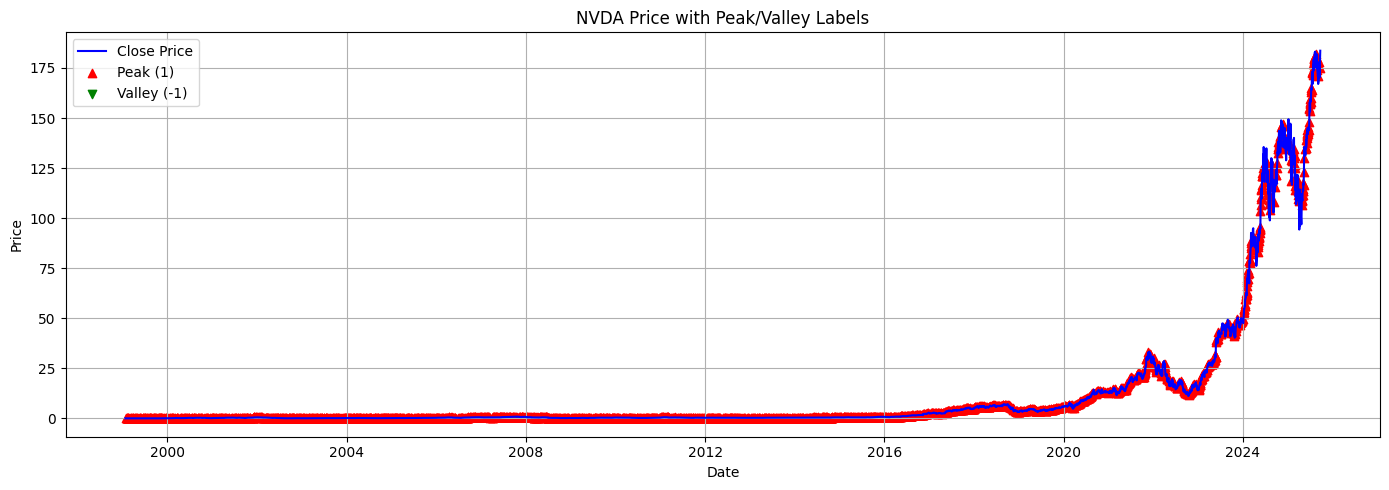

In [14]:
import matplotlib.pyplot as plt

# 日付型に変換
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

# 可視化：Close価格 + PeakLabel（山=赤点、谷=緑点）
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')

# 山（Peak=1）の位置に赤丸
peak_dates = data[data['trend_label'] == 1]
plt.scatter(peak_dates['Date'], peak_dates['Close'], color='red', label='Peak (1)', marker='^')

# 谷（Peak=-1）の位置に緑丸
valley_dates = data[data['trend_label'] == -1]
plt.scatter(valley_dates['Date'], valley_dates['Close'], color='green', label='Valley (-1)', marker='v')

plt.title(f"NVDA Price with Peak/Valley Labels")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


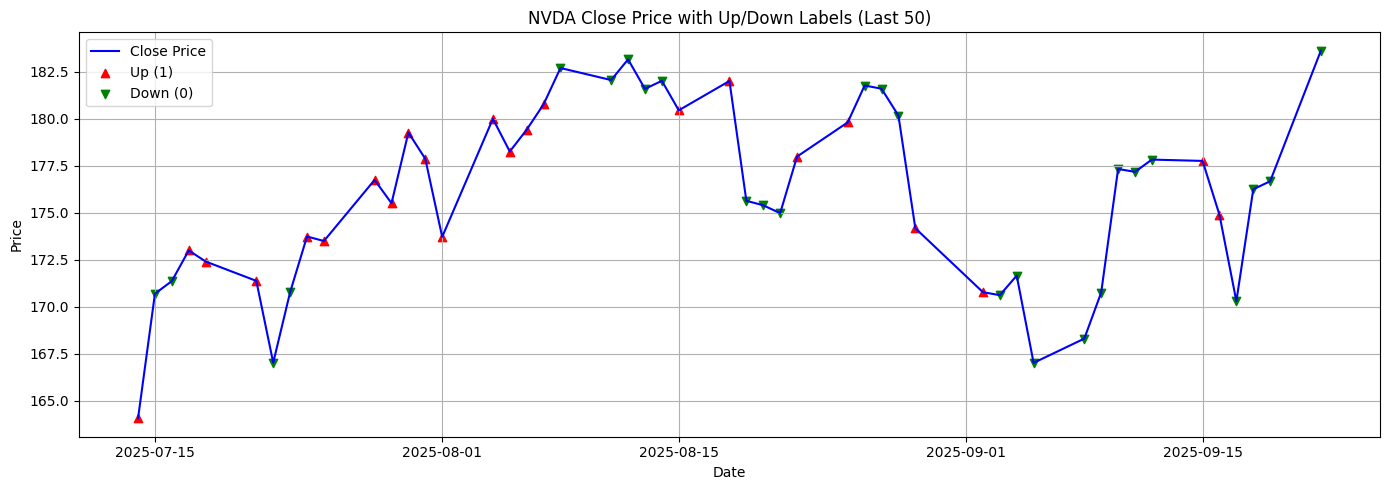

In [15]:
import matplotlib.pyplot as plt

data_last50 = data.tail(50)

plt.figure(figsize=(14, 5))
plt.plot(data_last50['Date'], data_last50['Close'], label='Close Price', color='blue')

# UpDown==1 (上がる) に赤三角
up_dates = data_last50[data_last50['trend_label'] == 1]
plt.scatter(up_dates['Date'], up_dates['Close'], color='red', label='Up (1)', marker='^')

# UpDown==0 (下がる) に緑逆三角
down_dates = data_last50[data_last50['trend_label'] == 0]
plt.scatter(down_dates['Date'], down_dates['Close'], color='green', label='Down (0)', marker='v')

plt.title("NVDA Close Price with Up/Down Labels (Last 50)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
data.dtypes

Date             datetime64[ns]
Close                   float64
High                    float64
Low                     float64
Open                    float64
Volume                    int64
dayofweek                 int64
is_month_end              int64
ma_5                    float64
ma_10                   float64
ma_ratio                float64
return_1                float64
return_5                float64
diff                    float64
rsi                     float64
macd                    float64
macd_signal             float64
bb_upper                float64
bb_lower                float64
bb_width                float64
vol_ma_5                float64
vol_change              float64
past_return             float64
future_return           float64
trend_label               int64
dtype: object

## ① 移動平均（MA）と終値グラフ

### ✅ 見方のポイント：
- **Close（黒線）**：実際の株価の終値
- **MA 5（青線）**：直近5期間（例：5日、5時間）の平均値
- **MA 10（オレンジ線）**：直近10期間の平均値

### 💡 解釈：
- **黒線が上に抜けたらトレンド上昇（ゴールデンクロス）** → 買いシグナル
- **黒線が下に抜けたらトレンド下降（デッドクロス）** → 売りシグナル
- 5MAと10MAの**乖離幅が大きいほど強いトレンド**

---

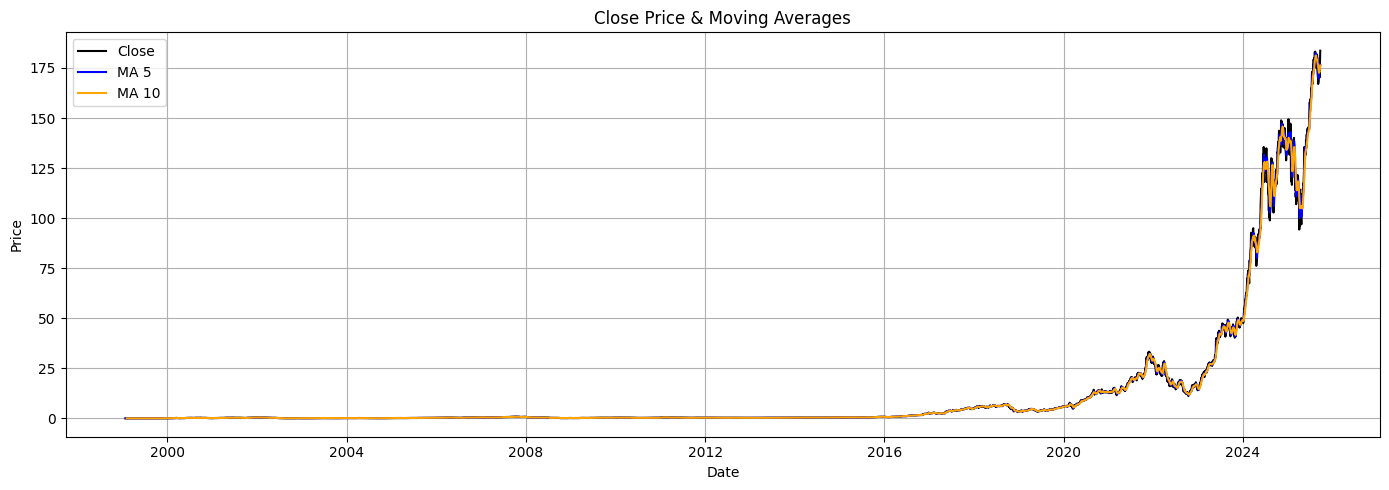

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close', color='black')
plt.plot(data['Date'], data['ma_5'], label='MA 5', color='blue')
plt.plot(data['Date'], data['ma_10'], label='MA 10', color='orange')
plt.title("Close Price & Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ② RSI（Relative Strength Index）

### ✅ 見方のポイント：
- RSIは **0～100の範囲**
- 一般的な基準：
  - 70以上：**買われすぎ** → 株価が下がるかも（売りシグナル）
  - 30以下：**売られすぎ** → 株価が上がるかも（買いシグナル）

### 💡 解釈：
- RSIが70を超えた後に下がり始めると**売り圧力**
- RSIが30を下回ってから上昇すると**買いの兆し**
- トレンド転換の可能性を**事前に察知する**のに使える

---

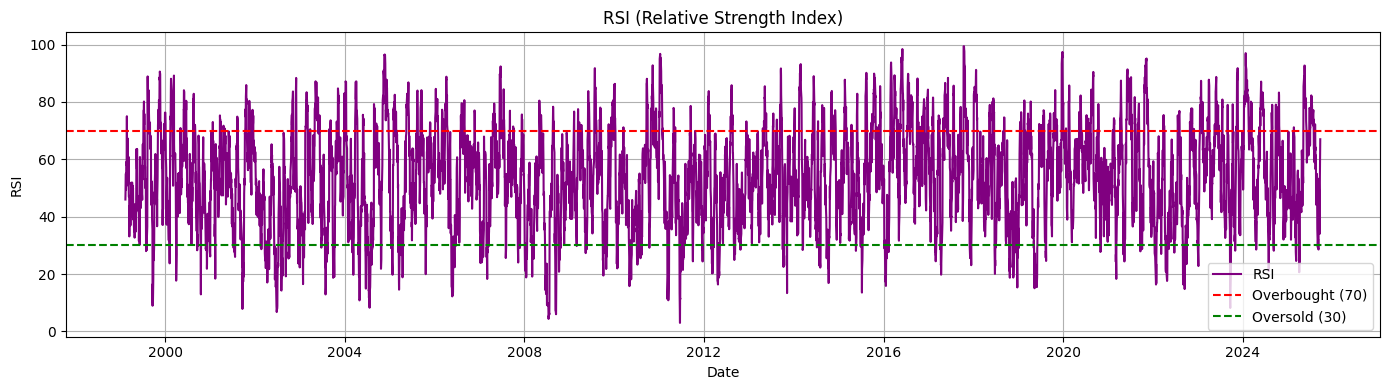

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(data['Date'], data['rsi'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.title("RSI (Relative Strength Index)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ③ MACD（移動平均収束拡散法）

### ✅ 見方のポイント：
- **MACD（青）**：短期EMA - 長期EMA（トレンドの強さ）
- **シグナル（赤）**：MACDの移動平均（9期間）

### 💡 解釈：
- **MACDがシグナルを上に抜ける** → 上昇トレンド（買い）
- **MACDがシグナルを下に抜ける** → 下降トレンド（売り）
- 上下の交差点が「トレンド転換のサイン」になる

---

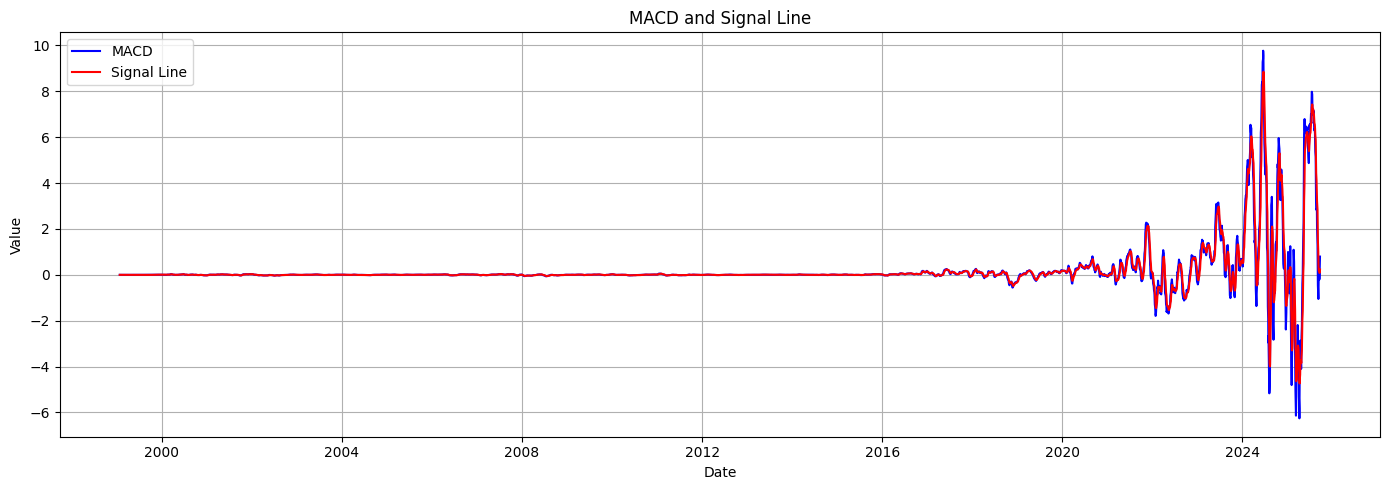

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['macd'], label='MACD', color='blue')
plt.plot(data['Date'], data['macd_signal'], label='Signal Line', color='red')
plt.title("MACD and Signal Line")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## ④ ボリンジャーバンド（Bollinger Band）

### ✅ 見方のポイント：
- 中央線：20期間の移動平均
- 上下のバンド：±2σ（標準偏差）の範囲
- 株価の約95%がこの中に収まる

### 💡 解釈：
- **上限に近い → 買われすぎ（反落の可能性）**
- **下限に近い → 売られすぎ（反発の可能性）**
- バンドが狭くなってから広がる時 → **ボラティリティ上昇（トレンド開始）**

---

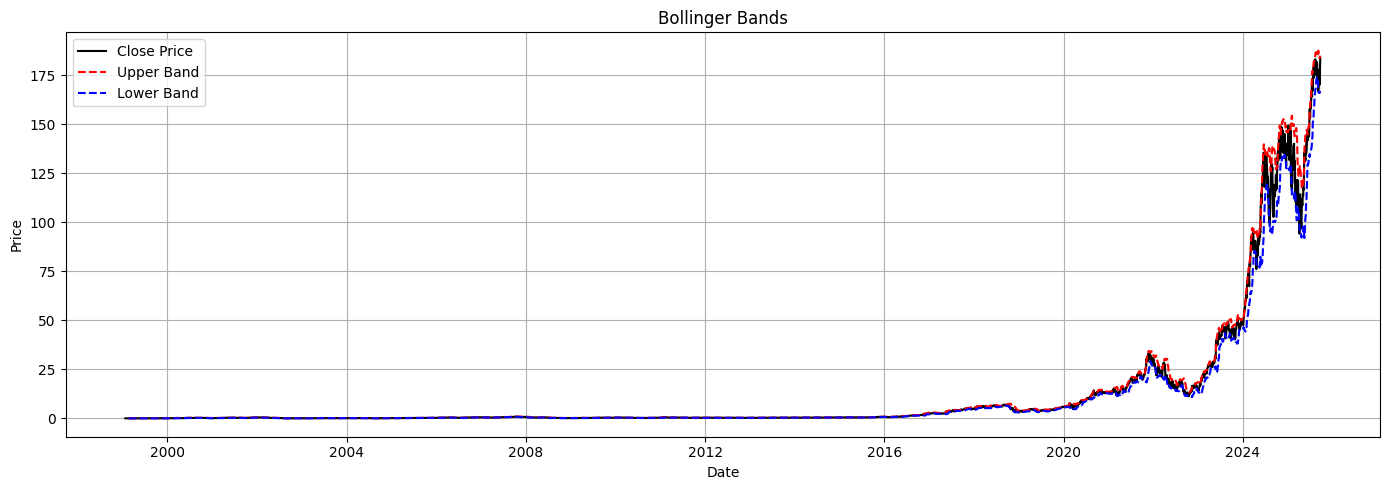

In [20]:
plt.figure(figsize=(14, 5))
plt.plot(data['Date'], data['Close'], label='Close Price', color='black')
plt.plot(data['Date'], data['bb_upper'], label='Upper Band', color='red', linestyle='--')
plt.plot(data['Date'], data['bb_lower'], label='Lower Band', color='blue', linestyle='--')
plt.fill_between(data['Date'], data['bb_lower'], data['bb_upper'], color='gray', alpha=0.1)
plt.title("Bollinger Bands")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ⑤ 出来高（Volume）と移動平均

### ✅ 見方のポイント：
- 灰色線：日々の出来高（取引量）
- 緑色線：直近5期間の平均出来高

### 💡 解釈：
- 出来高が平均より急増している → **注目度アップ、転換点の可能性**
- 出来高が増えながら価格が上昇 → **強い買い**
- 出来高が減っている → **様子見、方向感なし**

---

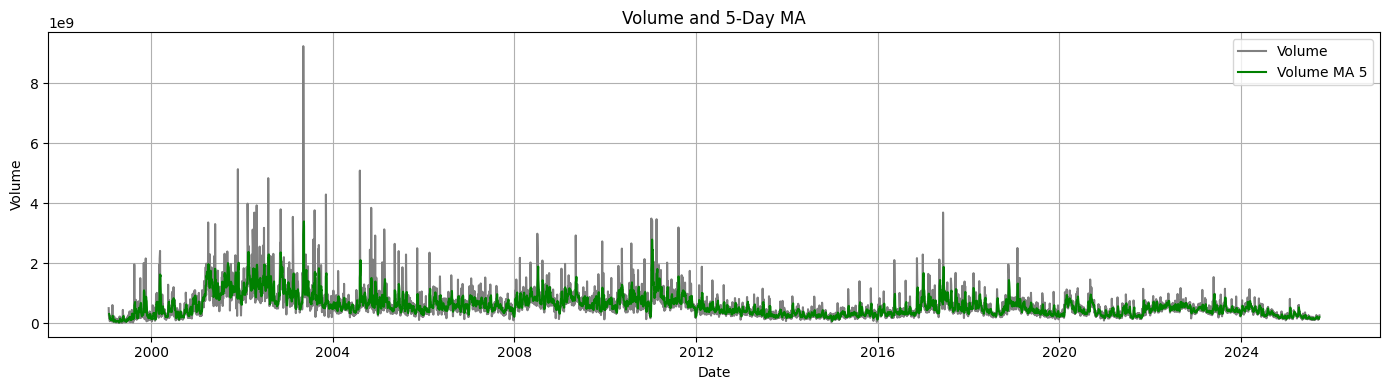

In [21]:
plt.figure(figsize=(14, 4))
plt.plot(data['Date'], data['Volume'], label='Volume', color='gray')
plt.plot(data['Date'], data['vol_ma_5'], label='Volume MA 5', color='green')
plt.title("Volume and 5-Day MA")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧠 総合的な見方

1. **RSIが高く、価格がBB上限を超えている** → **天井の可能性**
2. **MACDがシグナルを下抜け、出来高も上昇** → **本格的な売りトレンド開始**
3. **RSIが低く、価格がBB下限に接近＋MACDが上抜ける** → **反発の兆し**
4. **価格がMAより下でMACDも下** → **下降トレンド継続中**

---

In [22]:
data.head()

,Date,Close,High,Low,Open,Volume,dayofweek,is_month_end,ma_5,ma_10,...,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change,past_return,future_return,trend_label
0,1999-01-25,0.041547,0.042024,0.037607,0.040591,510480000,0,0,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.004537,0
1,1999-01-26,0.038323,0.042860,0.037726,0.042024,343200000,1,0,NaN,NaN,...,-0.000257,-0.000051,NaN,NaN,NaN,NaN,-0.327692,NaN,-0.004178,0
2,1999-01-27,0.038204,0.039398,0.036293,0.038442,244368000,2,0,NaN,NaN,...,-0.000465,-0.000134,NaN,NaN,NaN,NaN,-0.287972,NaN,-0.003343,0
3,1999-01-28,0.038084,0.038442,0.037845,0.038204,227520000,3,0,NaN,NaN,...,-0.000633,-0.000234,NaN,NaN,NaN,NaN,-0.068945,NaN,-0.001313,0
4,1999-01-29,0.036293,0.038204,0.036293,0.038084,244032000,4,0,0.03849,NaN,...,-0.000899,-0.000367,NaN,NaN,NaN,313920000.0,0.072574,NaN,0.001552,0


In [23]:
# 欠損値（NaN）を1つでも含む行を削除
data = data.dropna()

# インデックスを振り直す（オプション）
data = data.reset_index(drop=True)


In [24]:
print(data.columns.tolist())


['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'dayofweek', 'is_month_end', 'ma_5', 'ma_10', 'ma_ratio', 'return_1', 'return_5', 'diff', 'rsi', 'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width', 'vol_ma_5', 'vol_change', 'past_return', 'future_return', 'trend_label']


In [25]:
from sklearn.preprocessing import MinMaxScaler

# 正規処理
def normalize(data):
    features = [
    'Close', 'High', 'Low', 'Open', 'Volume', 
    'dayofweek', 'is_month_end', 'ma_5', 'return_5', 'diff', 'rsi',
    'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width',
    'vol_ma_5', 'vol_change'
    ]

    # スケーラのインスタンス化
    close_scaler = MinMaxScaler(feature_range=(0, 1))
    features_scaler = MinMaxScaler(feature_range=(0, 1))

    # スケーリングの適用
    #data['Peaklabel'] = close_scaler.fit_transform(data[['Peaklabel']]) 

    # 特徴量のスケーリング
    data[features] = features_scaler.fit_transform(data[features])

    return data, close_scaler, features_scaler

# 正規化の実行
data, close_scaler, features_scaler = normalize(data)
# 正規化後のデータの確認
data.head()

,Date,Close,High,Low,Open,Volume,dayofweek,is_month_end,ma_5,ma_10,...,macd,macd_signal,bb_upper,bb_lower,bb_width,vol_ma_5,vol_change,past_return,future_return,trend_label
0,1999-02-22,0.000048,0.000046,0.000041,0.000047,0.020146,0.00,0.0,0.000039,0.038060,...,0.390340,0.348705,0.000039,0.000030,0.000107,0.026170,0.285729,0.000238,0.002030,1
1,1999-02-23,0.000059,0.000056,0.000045,0.000050,0.012856,0.25,0.0,0.000041,0.038609,...,0.390358,0.348717,0.000040,0.000030,0.000111,0.021829,0.058707,0.001910,-0.000238,0
2,1999-02-24,0.000077,0.000095,0.000076,0.000089,0.064388,0.50,0.0,0.000049,0.039636,...,0.390389,0.348734,0.000048,0.000025,0.000163,0.054281,0.475438,0.007402,-0.006447,0
3,1999-02-25,0.000069,0.000087,0.000070,0.000084,0.014054,0.75,0.0,0.000055,0.040555,...,0.390406,0.348751,0.000053,0.000023,0.000189,0.058951,0.011166,0.005373,-0.005851,0
4,1999-02-26,0.000058,0.000072,0.000061,0.000068,0.016602,1.00,0.0,0.000057,0.040973,...,0.390408,0.348765,0.000055,0.000023,0.000197,0.064741,0.112349,0.002029,-0.001671,0


In [26]:
features_cols = ['Close', 'High', 'Low', 'Open', 'Volume', 
    'dayofweek', 'is_month_end', 'ma_5', 'return_5', 'diff', 'rsi',
    'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'bb_width',
    'vol_ma_5', 'vol_change']

target_cols = ['trend_label']

In [27]:
import numpy as np

def create_sequences(data, seq_length, target_col='trend_label'):
    X, y = [], []  # 入力データ（特徴量系列）と正解ラベルのリストを初期化
    
    # データをseq_length（例:10）ずつスライドさせながら
    # 連続した特徴量の部分系列を抽出し、教師ラベルを取得するループ
    for i in range(len(data) - seq_length):
        # i番目からi+seq_length番目までの特徴量部分系列を取得（2次元配列）
        # features_cols は使用する特徴量列名のリスト（事前に定義されている想定）
        X.append(data.iloc[i:i+seq_length][features_cols].values)
        
        # i+seq_length番目のターゲット列の値（教師ラベル）を取得
        y.append(data.iloc[i + seq_length][target_col])
    
    # リストをNumPy配列に変換して返す
    # Xの形状は (サンプル数, seq_length, 特徴量数)
    # yの形状は (サンプル数,)
    return np.array(X), np.array(y)

# シーケンス長（時系列の長さ）を10に設定
SEQ_LENGTH = 10

# 関数を使ってノイズなしの時系列シーケンスXとラベルyを作成
X, y = create_sequences(data, SEQ_LENGTH)

# 結果の配列の形状を表示
print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (6678, 10, 18) y shape: (6678,)


In [28]:
from tensorflow.keras.utils import to_categorical

def train_test_split_one_hot_binary(X, y, test_size=0.2):
    """
    LSTMなどの2クラス分類モデル用に時系列データを分割し、yをone-hotエンコードする関数。
    - yは [0, 1] の2クラスラベルを想定。
    """
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    y_train = to_categorical(y_train, num_classes=2)
    y_test = to_categorical(y_test, num_classes=2)

    return X_train, X_test, y_train, y_test

def train_test_split_raw_label(X, y, test_size=0.2):
    """
    XGBoostなどラベルのまま使うモデル用に時系列データを分割する関数（yは0 or 1）
    """
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    return X_train, X_test, y_train, y_test

TEST_SIZE = 0.2
# LSTM用（2クラスのone-hotラベル）
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split_one_hot_binary(X, y, test_size=TEST_SIZE)

# XGBoost用（整数ラベル）
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split_raw_label(X, y, test_size=TEST_SIZE)

# XGBoostの入力を2次元に変換（flatten）
xgb_X_train = X_train_xgb.reshape(X_train_xgb.shape[0], -1)
xgb_X_test = X_test_xgb.reshape(X_test_xgb.shape[0], -1)



# モデル構築

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


def build_lstm_model(input_shape, lstm_units=64, dense_units=32, dropout_rate=0.2, learning_rate=0.001):
    """3クラス分類用LSTMモデルを構築"""
    model = Sequential([
        # LSTM層（時系列特徴抽出）
        LSTM(lstm_units, return_sequences=True, input_shape=input_shape),
        BatchNormalization(),
        Dropout(dropout_rate),

        # 2つ目のLSTM（時系列の要約）
        LSTM(lstm_units // 2),
        BatchNormalization(),
        Dropout(dropout_rate),

        # 全結合層
        Dense(dense_units, activation='relu'),

        # 出力層：2クラス分類 → softmax
        Dense(2, activation='softmax')
    ])

    # クロスエントロピー＋精度
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


SEQ_LENGTH = 5  # 時系列の長さ（例：30日分のデータを使用）

# モデルの構築
lstm_model = build_lstm_model((SEQ_LENGTH, X_train_lstm.shape[2])) # 時系列の長さ，特徴量の数
lstm_model.summary() # モデルの概要

2025-10-14 14:12:15.815681: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-10-14 14:12:15.815735: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-10-14 14:12:15.815739: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
I0000 00:00:1760418735.815794 8094193 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1760418735.815858 8094193 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/yasuo/myenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instea

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,170 (137.38 KB)

 Trainable params: 34,978 (136.63 KB)

 Non-trainable params: 192 (768.00 B)

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_lstm_classification(y_true, y_pred):
    """LSTMモデル（分類）の評価関数"""

    # One-hot → ラベル（[0, 1, 0] → 1）
    y_true_labels = y_true.argmax(axis=1) if len(y_true.shape) > 1 else y_true
    y_pred_labels = y_pred.argmax(axis=1) if len(y_pred.shape) > 1 else y_pred

    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

    print("LSTMモデルの評価結果")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

# LSTMモデルの予測（softmax出力）
lstm_pred = lstm_model.predict(X_test_lstm)

# 評価実行
evaluate_lstm_classification(y_test_lstm, lstm_pred)


2025-10-14 14:12:17.685194: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
LSTMモデルの評価結果
Accuracy : 0.5344
Precision: 0.5184
Recall   : 0.5115
F1 Score : 0.4718


In [31]:
import xgboost as xgb


# XGBoostモデルの構築
def build_xgboost_classifier(n_estimators=100, max_depth=5, learning_rate=0.1):
    model = xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42
    )
    return model


# XGBoostモデルの構築
xgb_X_train = X_train_xgb.reshape(X_train_xgb.shape[0],-1) # 2次元に変換
xgb_X_test = X_test_xgb.reshape(X_test_xgb.shape[0],-1) # 2次元に変換

# モデルの構築
xgb_model = build_xgboost_classifier()

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def convert_regression_to_binary(y_pred):
    """
    XGBoost回帰の連続値予測を2クラス（0 or 1）に変換する関数。
    0.0未満 → 0（下がる）
    0.0以上 → 1（上がる）
    """
    return (y_pred >= 0).astype(int)

def evaluate_xgboost_binary(y_true, y_pred):
    """XGBoost回帰の予測を2クラスに変換して評価"""
    y_true_labels = y_true.astype(int)
    y_pred_labels = convert_regression_to_binary(y_pred)

    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    precision = precision_score(y_true_labels, y_pred_labels, zero_division=0)
    recall = recall_score(y_true_labels, y_pred_labels, zero_division=0)
    f1 = f1_score(y_true_labels, y_pred_labels, zero_division=0)

    print("XGBoostモデル（二値分類）の評価結果")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")


# XGBoostモデルの学習
xgb_model.fit(xgb_X_train, y_train_xgb)

# 予測
xgb_pred = xgb_model.predict(xgb_X_test)

# 評価実行
evaluate_xgboost_binary(y_test_xgb, xgb_pred)


XGBoostモデル（二値分類）の評価結果
Accuracy : 0.5374
Precision: 0.5374
Recall   : 1.0000
F1 Score : 0.6991


In [33]:
data['trend_label'].value_counts()

trend_label
1    3413
0    3275
Name: count, dtype: int64

In [34]:
y_test_xgb

array([1, 0, 1, ..., 0, 0, 0])

In [35]:
xgb_pred

array([0, 0, 0, ..., 0, 0, 1])

# 訓練モデル

In [36]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 早期停止
early_stopping = EarlyStopping(
    monitor='val_loss',  # 検証データの損失値を監視
    patience=10,  # 10エポック改善が見られない場合に停止
    restore_best_weights=True  # 最適な重みを復元
)

# モデルの保存
checkpoint = ModelCheckpoint(
    'model/best_model.keras',  # ベストなモデルの重みを保存
    save_best_only=True,  # 検証データの損失が改善した場合のみに保存
)

# LSTMモデルの学習
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,  # トレーニングデータ
    epochs=100,  # エポック数
    batch_size=32,  # バッチサイズ
    validation_split=0.2,  # 検証データの割合
    callbacks=[early_stopping, checkpoint],  # コールバック
    verbose=1  # ログの表示
)


Epoch 1/100


134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.4960 - loss: 0.8661 - val_accuracy: 0.4855 - val_loss: 0.6948
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.5362 - loss: 0.7189 - val_accuracy: 0.4799 - val_loss: 0.6945
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5137 - loss: 0.7007 - val_accuracy: 0.4986 - val_loss: 0.6957
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5342 - loss: 0.6903 - val_accuracy: 0.4846 - val_loss: 0.7387
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.5414 - loss: 0.6929 - val_accuracy: 0.5061 - val_loss: 0.7037
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5041 - loss: 0.6983 - val_accuracy: 0.5239 - val_loss: 0.6980
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5164 - loss: 0.6974 - val_accuracy: 0.4790 - val_loss: 0.7432
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.5288 - loss: 0.6937 - val_accurac

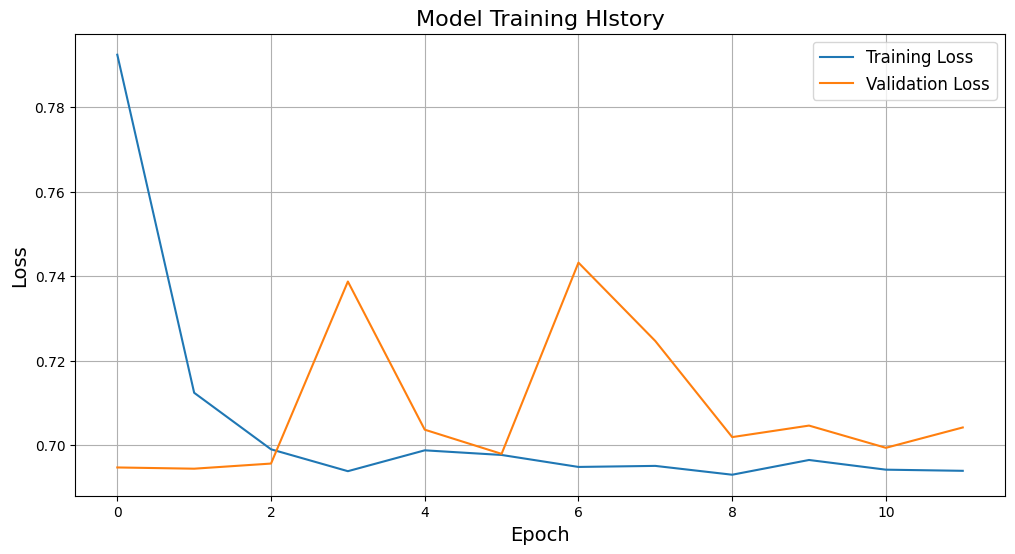

In [37]:
# 訓練の履歴をプロット
def plot_training_history(history):
    """訓練履歴と損失のプロット"""
    plt.figure(figsize=(12,6)) # グラフのサイズ

    plt.plot(history.history['loss'],label='Training Loss') # 訓練データの損失
    plt.plot(history.history['val_loss'],label='Validation Loss') # 検証データの損失

    plt.title('Model Training HIstory',fontsize=16) # タイトル
    plt.xlabel('Epoch',fontsize=14) # X軸ラベル
    plt.ylabel('Loss',fontsize=14) # Y軸ラベル
    plt.legend(fontsize=12) # 凡例
    plt.grid(True) # グリッド線
    plt.show() # グラフの表示

plot_training_history(history)
# (補足)検証損失とはみたこと無いデータに対しての誤差を表す

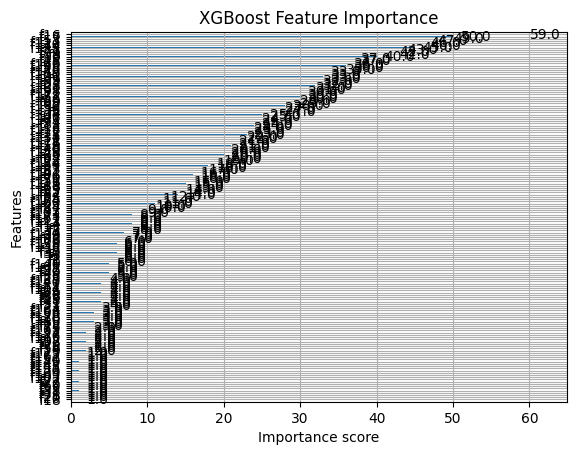

In [38]:
# Train XGBoost model
xgb_model.fit(xgb_X_train, y_train_xgb) # XGBoostモデルの学習

# Feature importance
xgb.plot_importance(xgb_model) # 特徴量の重要度をプロット
plt.title('XGBoost Feature Importance') # タイトル
plt.show() # グラフの表示

# ハイブリッドモデル &評価

In [40]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 以前定義したXGBoost回帰予測を-1,0,1のクラスに丸める関数
def convert_regression_to_class(y_pred):
    y_class = np.where(y_pred < -0.5, -1,
               np.where(y_pred < 0.5, 0, 1))
    return y_class.astype(int)

# XGBoostのクラスをLSTMの0,1,2ラベル空間に変換
def convert_xgb_label_to_lstm_label(y_pred):
    y_class = convert_regression_to_class(y_pred)  # -1,0,1
    y_shifted = y_class + 1  # -1->0, 0->1, 1->2
    return y_shifted.astype(int)

# XGBoost予測をLSTMラベル形式の確率ベクトルに変換
def xgb_to_prob_lstm_labels(xgb_pred):
    y_lstm_labels = convert_xgb_label_to_lstm_label(xgb_pred)
    n_samples = len(y_lstm_labels)
    probs = np.zeros((n_samples, 3))
    for i, label in enumerate(y_lstm_labels):
        probs[i, label] = 1.0
    return probs

# --- ここからハイブリッドモデルの評価処理 ---

# LSTMモデルの予測（0,1,2の確率ベクトル）
lstm_pred_prob = lstm_model.predict(X_test_lstm)  # shape (n_samples, 3)

# XGBoostモデルの予測（連続値）
xgb_pred_raw = xgb_model.predict(xgb_X_test)

# XGBoost予測を確率ベクトルに変換（LSTMのラベル空間に合わせる）
xgb_pred_prob = xgb_to_prob_lstm_labels(xgb_pred_raw)

# アンサンブル（重み付け平均）
alpha = 0.8  # LSTM重視
ensemble_prob = alpha * lstm_pred_prob + (1 - alpha) * xgb_pred_prob

# 最終予測クラス（0,1,2）
final_pred = ensemble_prob.argmax(axis=1)

# 正解ラベル（-1,0,1 → 0,1,2に変換）
y_true = (y_test_xgb + 1).astype(int)

# 評価指標計算
print("ハイブリッドモデル評価")
print(f"Accuracy:  {accuracy_score(y_true, final_pred):.4f}")
print(f"Precision: {precision_score(y_true, final_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_true, final_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_true, final_pred, average='macro', zero_division=0):.4f}")


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


ValueError: operands could not be broadcast together with shapes (1336,2) (1336,3) 

In [ ]:
print(y_test_lstm[:5])
print(y_test_lstm.shape)

print(lstm_pred[:5])
print(lstm_pred.shape)



[[1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]
(1325, 2)
[[0.49524415 0.50475585]
 [0.49450722 0.5054928 ]
 [0.49426743 0.50573254]
 [0.49516532 0.5048347 ]
 [0.494954   0.505046  ]]
(1325, 2)


In [ ]:
from collections import Counter
print(Counter(y))  # 前処理前の y を確認


Counter({np.int64(1): 3423, np.int64(0): 3200})


In [ ]:
y_pred = lstm_model.predict(X_test_lstm)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test_lstm, axis=1)

# ラベル分布
import numpy as np
print("予測ラベルの分布:", np.bincount(final_pred))
print("正解ラベルの分布:", np.bincount(y_true_labels))

# 混同行列
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_labels, final_pred, labels=[0,1,2])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


NameError: name 'final_pred' is not defined

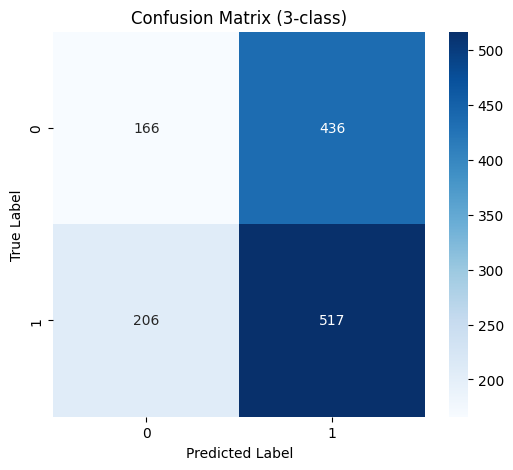

[[166 436]
 [206 517]]


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ラベル変換
true_labels = y_test_lstm.argmax(axis=1) if len(y_test_lstm.shape) > 1 else y_test_lstm
pred_labels = lstm_pred.argmax(axis=1)

# クラス数を明示的に指定（0, 1, 2）
labels = [0, 1]

# 混同行列の計算
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# ヒートマップ表示
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (3-class)')
plt.show()

print(cm)